# FFN: FOGD and NZK ZOGD (function space)

In [1]:
import torch
import torch.nn as nn

from matplotlib import pyplot as plt
import numpy as np

from torchvision import transforms

import copy, cv2
import os, time
from datasets import load_dataset
import skimage
from PIL import Image
from scipy.io import loadmat, savemat
torch.manual_seed(0)

eta_fo = 1e-3  # FOGD step size
eta_zo = 1e-3  # ZOGD step size

resolution = 8
sample_num = 100

digit_negative = 2
digit_positive = 9

iteration_total = 16000
function_record_iteration_list = [0, 99, 999, 3999, 4999, 5999, 8999, 9999, iteration_total - 1]

ds = load_dataset("zh-plus/tiny-imagenet").with_format("np")

In [2]:
output_folder = os.path.join('output_FFN_zo_fo_imagenet', 'linearized_imagenet_linear_{}_{}_{}'.format(resolution, digit_negative, digit_positive))
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

## Data loading

In [3]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()  
])

idx_negative = np.random.choice(ds['train']['image'][ds['train']['label'] == digit_negative].shape[0], sample_num)
idx_positive = np.random.choice(ds['train']['image'][ds['train']['label'] == digit_positive].shape[0], sample_num)
# extract the images and resize them to 8x8
image_negative = ds['train']['image'][ds['train']['label'] == digit_negative][idx_negative]
image_negative = np.array([cv2.resize(image, (resolution, resolution)) for image in image_negative])
image_negative = torch.stack([transform(Image.fromarray(img)) for img in image_negative]).flatten(1)

image_positive = ds['train']['image'][ds['train']['label'] == digit_positive][idx_positive]
image_positive = np.array([cv2.resize(image, (resolution, resolution)) for image in image_positive])
image_positive = torch.stack([transform(Image.fromarray(img)) for img in image_positive]).flatten(1)


In [4]:
train_data = torch.from_numpy(np.concatenate((image_negative, image_positive), axis=0)).float()
train_label = torch.from_numpy(np.concatenate((np.zeros(sample_num), np.ones(sample_num)))).float().reshape(-1, 1)

random_idx = np.random.permutation(train_data.shape[0])
train_data = train_data[random_idx]
train_label = train_label[random_idx]

## Network, data, and targets

In [5]:
class non_linear_function(nn.Module):
    def __init__(self, input_dim: int=2, hidden_dim: list[int] = [10,5], output_dim: int = 1):
        super(non_linear_function, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim[0]),
            nn.ReLU(),
        )
        for i in range(0, len(hidden_dim)-1):
            self.net.append(nn.Linear(hidden_dim[i], hidden_dim[i+1]))
            self.net.append(nn.ReLU())
        self.net.append(nn.Linear(hidden_dim[-1], output_dim))


    def forward(self, x):
        mid = torch.tensor([]).float().to(x.device)
        for layer in self.net:
            x = layer(x)
            mid = torch.cat((mid, x), dim=1)
        return x, mid
        

In [6]:
network = non_linear_function(input_dim=resolution*resolution, hidden_dim=[10, 5], output_dim=1)
train_data = train_data.cuda()
train_label = train_label.cuda()
network = network.cuda()

## Jacobian features (linearized model)

In [7]:
x_preprocessed = []

theta_0 = torch.cat([p.reshape(-1) for p in network.parameters()])

with torch.no_grad():
    model_0, _ = network(train_data)
    model_0 = model_0.detach()

for x_ in train_data:
    network.zero_grad()
    x_pred, mid = network(x_.unsqueeze(0))
    gradient = torch.autograd.grad(x_pred, network.parameters(), grad_outputs=torch.ones_like(x_pred), create_graph=True)
    x_preprocessed.append(torch.cat([gradient[i].reshape(-1) for i in range(len(gradient))]))

x_preprocessed = torch.stack(x_preprocessed)

N = x_preprocessed.shape[1]
x = copy.deepcopy(x_preprocessed.detach())
y = copy.deepcopy(train_label)

## FOGD

In [ ]:
loss_list_fo = torch.tensor([])
f_diff_list_fo = torch.tensor([])

NTK_kernal_fo = x @ x.t()

theta_fo = copy.deepcopy(theta_0.detach()).view(-1, 1)
f_0 = x_preprocessed @ theta_fo

f_fo_list = torch.Tensor([])

# fit 1000 
with torch.no_grad():
    for i in range(iteration_total):
        
        loss_0 = 1/2 * (f_0 - y).pow(2).mean() # compute the mean loss for whole dataset first
        loss_list_fo = torch.cat((loss_list_fo, loss_0.view(1).cpu()))
        
        f_1 = f_0 - eta_fo / sample_num * NTK_kernal_fo.T @ (f_0 - y)
        
        f_diff = f_1 - f_0
        
        if i in function_record_iteration_list:
            f_fo_list = torch.cat((f_fo_list, f_0.unsqueeze(0).cpu()))
        f_diff_list_fo = torch.cat((f_diff_list_fo, f_diff.view(1, -1).cpu()))
        f_0 = f_1
        print('iteration: {}, loss: {}'.format(i, loss_0)) if i % 2000 == 0 else None
        
f_final_fo = f_0

iteration: 0, loss: 0.28262484073638916
iteration: 2000, loss: 0.12280122190713882
iteration: 4000, loss: 0.12249880284070969
iteration: 6000, loss: 0.12220963835716248
iteration: 8000, loss: 0.12192746996879578
iteration: 10000, loss: 0.12165147811174393
iteration: 12000, loss: 0.12138194590806961
iteration: 14000, loss: 0.1211201623082161


## NZK ZOGD

In [9]:
NTK_list_sample = torch.tensor([]).cuda()

for i in range(10000):
    z = torch.normal(0.0, 1.0, size=(1, N)).cuda()
    z = z.repeat(train_data.shape[0], 1)
    
    first_term = z @ x.T
    second_term = z @ x.T # zeta = z
    third_term = z @ z.T
    
    NTK_zo_temp = first_term.T * second_term * third_term

    NTK_list_sample = torch.cat((NTK_list_sample, NTK_zo_temp.unsqueeze(0)))
    
NZK_kernal_zo = NTK_list_sample.mean(dim=0)

In [10]:
f_diff_list_zo = torch.tensor([])
loss_list_zo = torch.tensor([])
theta_zo = copy.deepcopy(theta_0.detach()).view(-1, 1)

f_zo_list = torch.Tensor([])

f_0 = x_preprocessed @ theta_zo

for i in range(iteration_total):

    loss_0 = 1/2 * (f_0 - y).pow(2).mean()
    loss_list_zo = torch.cat((loss_list_zo, loss_0.view(1).cpu()))
    
    f_1 = f_0 - eta_zo / sample_num * NZK_kernal_zo.T @ (f_0 - y)
    
    f_diff = f_1 - f_0
    f_diff_list_zo = torch.cat((f_diff_list_zo, f_diff.view(1, -1).cpu()))
    
    if i in function_record_iteration_list:
        f_zo_list = torch.cat((f_zo_list, f_0.unsqueeze(0).cpu()))
    
    f_0 = f_1
    print('iteration: {}, loss: {}'.format(i, loss_0)) if i % 2000 == 0 else None


f_final_zo = f_0 

iteration: 0, loss: 0.28262484073638916
iteration: 2000, loss: 0.08141186833381653
iteration: 4000, loss: 0.07104161381721497
iteration: 6000, loss: 0.06607816368341446
iteration: 8000, loss: 0.06295429915189743
iteration: 10000, loss: 0.060645684599876404
iteration: 12000, loss: 0.05877944827079773
iteration: 14000, loss: 0.057190902531147


In [11]:
standard_loss_list_zo = torch.tensor([])
standard_theta_zo = copy.deepcopy(theta_0.detach()).view(-1, 1)
epsilon = 1e-3

minibatch = 100

def l2_loss(x, theta, y):
    return 1/2 * (x @ theta - y).pow(2).mean()

for i in range(iteration_total):
    
    loss_0 = l2_loss(x, standard_theta_zo, y)
    standard_loss_list_zo = torch.cat((standard_loss_list_zo, loss_0.view(1).cpu()))
    
    loss_diff_best = -10
    z_best = None
    
    for j in range(minibatch):
    
        z = torch.normal(0.0, 1.0, size=(1, N)).cuda()
    
        local_diff = (l2_loss(x, standard_theta_zo + epsilon * z, y) - l2_loss(x, standard_theta_zo - epsilon * z, y))
        if local_diff > loss_diff_best:
            loss_diff_best = local_diff
            z_best = z

    standard_theta_zo = standard_theta_zo - eta_zo * loss_diff_best / (2 * epsilon) * z_best
            
    
    print('iteration: {}, loss: {}'.format(i, loss_0)) if i % 2000 == 0 else None

iteration: 0, loss: 0.28262484073638916
iteration: 2000, loss: 0.2480504810810089
iteration: 4000, loss: 0.22241830825805664
iteration: 6000, loss: 0.20339107513427734
iteration: 8000, loss: 0.18944142758846283
iteration: 10000, loss: 0.17916010320186615
iteration: 12000, loss: 0.17160874605178833
iteration: 14000, loss: 0.16596682369709015


In [12]:
# --------------------- save all data ---------------------
savemat(os.path.join(output_folder, 'data.mat'), {
    'idx_negative': idx_negative,
    'idx_positive': idx_positive,
    'random_idx': random_idx,
    'f_fo_list': f_fo_list.numpy(),
    'f_zo_list': f_zo_list.detach().numpy(),
    'loss_list_fo': loss_list_fo.numpy(),
    'loss_list_zo': loss_list_zo.detach().numpy(),
    'f_diff_list_fo': f_diff_list_fo.numpy(),
    'f_diff_list_zo': f_diff_list_zo.detach().numpy(),
    'function_record_iteration_list': function_record_iteration_list,
    'x_preprocessed': x_preprocessed.detach().cpu().numpy(),
    'initial_theta': theta_0.detach().cpu().numpy(),
    'NTK_kernal_fo': NTK_kernal_fo.detach().cpu().numpy(),
    'NZK_kernal_zo': NZK_kernal_zo.detach().cpu().numpy()
})

# save the target_ffn_network parameters and network structure
torch.save(network, os.path.join(output_folder, 'initial_network.pth'))

## Plots (2D)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from matplotlib import cm
from mpl_toolkits.mplot3d.axes3d import get_test_data
from mpl_toolkits.axes_grid1 import make_axes_locatable

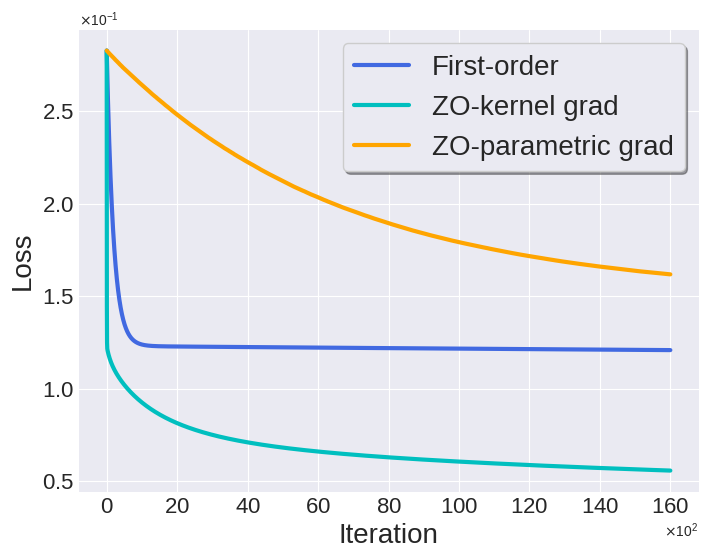

In [14]:
# plot the loss_list_fo and loss_list_zo
plt.style.use('seaborn-v0_8-darkgrid')

sf = plt.figure(figsize=(8,6), dpi=100)
ax = sf.add_subplot()
plt.plot(loss_list_fo[:].detach().numpy(),color='royalblue',label='First-order', linewidth=3)
plt.plot(loss_list_zo[:].detach().numpy(),color='c',label='ZO-kernel grad', linewidth=3)
plt.plot(standard_loss_list_zo[:].detach().numpy(),color='orange',label='ZO-parametric grad', linewidth=3)

plt.tick_params(axis='both', which='major', top='on', right='on', direction='in', labelsize=16)
plt.ticklabel_format(style='sci', scilimits=(0,2), axis='y',useMathText=True)
plt.ticklabel_format(style='sci', scilimits=(2,2), axis='x',useMathText=True)
plt.legend(fancybox=True, shadow=True,fontsize=20, frameon=True)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.show()

sf.savefig(os.path.join(output_folder,'loss.pdf'), bbox_inches='tight')

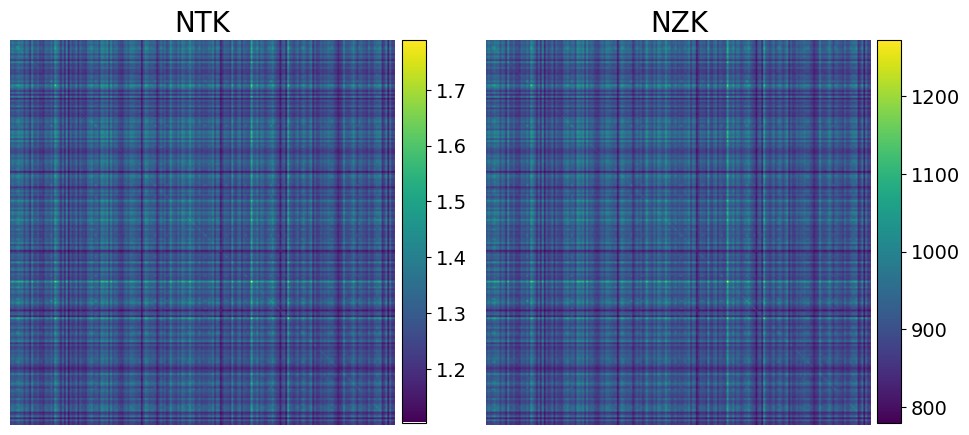

In [15]:
# return to defualt style
plt.style.use('default')
grid = plt.GridSpec(1, 2, wspace = 0.05, hspace = 0.05)

fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(grid[0, 0])

norm_fo = plt.Normalize(NTK_kernal_fo.min(), NTK_kernal_fo.max())
ax.imshow(NTK_kernal_fo.detach().cpu().numpy(), label='NTK')
ax.title.set_text('NTK')
ax.title.set_fontsize(20)
ax.axis('off')
cbar_ax = fig.add_axes([0.48, 0.115, 0.02, 0.765])
cbar_ax.tick_params(labelsize=14)
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm_fo)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)


ax = fig.add_subplot(grid[0, 1])
norm_zo = plt.Normalize(NZK_kernal_zo.min(), NZK_kernal_zo.max())
ax.imshow(NZK_kernal_zo.detach().cpu().numpy(), label='NZK')
ax.title.set_text('NZK')
ax.title.set_fontsize(20)
ax.axis('off')
# add colorbar

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
cbar_ax = fig.add_axes([0.876, 0.115, 0.02, 0.765])
cbar_ax.tick_params(labelsize=14)
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm_zo)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)
plt.show()
fig.savefig(os.path.join(output_folder,'NTK_NZK.pdf'), bbox_inches='tight')